In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded successfully!')


Libraries loaded successfully!


In [9]:
df = pd.read_csv('creditcard.csv')

In [10]:
print('Dataset loaded!')

Dataset loaded!


In [11]:
print(f'Shape: {df.shape}')  ##Shows rows and columns
df.head()                       ## Shows only first 5 rows      

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [14]:
## Basic data set information   ##Exploratory Data Analysis (EDA)
print('=== DATASET SHAPE ===')
print(df.shape)


=== DATASET SHAPE ===
(284807, 31)


In [15]:
print('\n=== COLUMN NAMES ===')
print(df.columns.tolist())



=== COLUMN NAMES ===
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [16]:
print('\n=== DATA TYPES ===')
print(df.dtypes)



=== DATA TYPES ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [17]:
print('\n=== STATISTICAL SUMMARY ===')
df.describe()




=== STATISTICAL SUMMARY ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [18]:
## Than we will check for null values in our data set
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')


Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values: 0


In [19]:
# Cell 5: Class Distribution
print('Class counts:')
print(df['Class'].value_counts())
print(f'\nFraud percentage: {df["Class"].mean()*100:.3f}%')



Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.173%


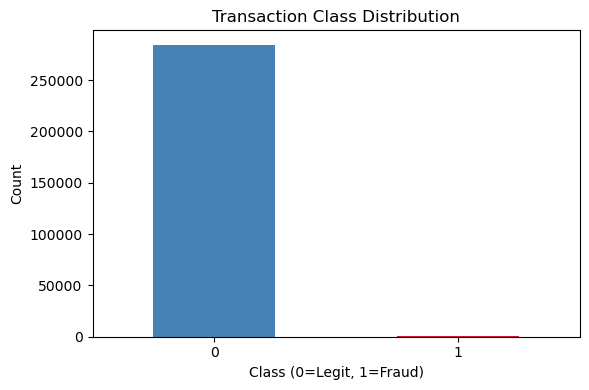

In [20]:
# Bar chart
plt.figure(figsize=(6,4))
df['Class'].value_counts().plot(kind='bar', color=['steelblue','crimson'])
plt.title('Transaction Class Distribution')
plt.xlabel('Class (0=Legit, 1=Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


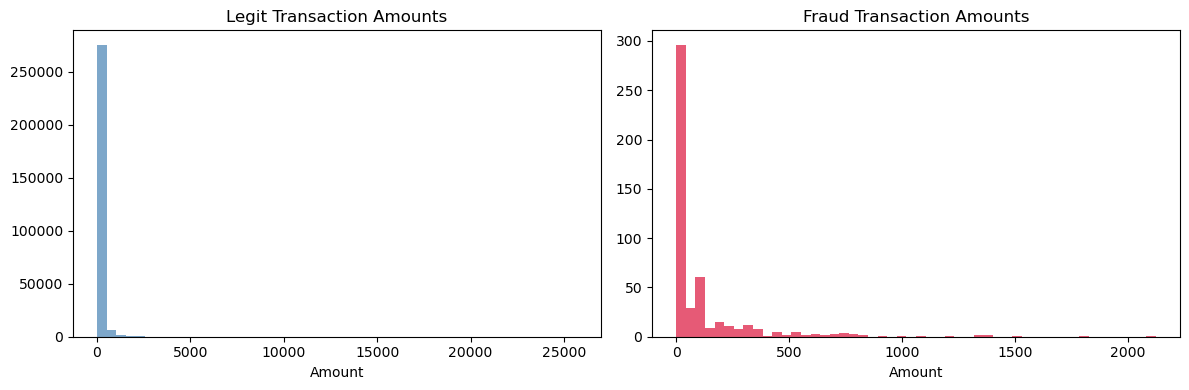

Fraud Amount Stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [21]:
## Now we will analyze the Transaction Amounts

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7, color='steelblue')
ax1.set_title('Legit Transaction Amounts'); ax1.set_xlabel('Amount')
ax2.hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7, color='crimson')
ax2.set_title('Fraud Transaction Amounts'); ax2.set_xlabel('Amount')
plt.tight_layout()
plt.show()
print('Fraud Amount Stats:')
print(df[df['Class']==1]['Amount'].describe())


In [22]:
## Remoing Irrelevant information
df = df.drop(['Time'], axis=1)
print('Remaining columns:', df.shape[1])


Remaining columns: 30


In [23]:
##•	The V1-V28 features are already PCA-transformed and roughly centered around 0 with small values. But 'Amount' can be anywhere from 0 to thousands of euros — a completely different scale so we will transform the amount

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
print('Amount after scaling:')
print(df['Amount'].describe())



Amount after scaling:
count    2.848070e+05
mean    -3.672378e-17
std      1.000002e+00
min     -3.532294e-01
25%     -3.308401e-01
50%     -2.652715e-01
75%     -4.471707e-02
max      1.023622e+02
Name: Amount, dtype: float64


In [24]:
X = df.drop('Class', axis=1)   # Everything except the label
y = df['Class']                # The label: 0=legit, 1=fraud
print('X shape:', X.shape)
print('y shape:', y.shape)
print('Fraud cases in y:', y.sum())


X shape: (284807, 29)
y shape: (284807,)
Fraud cases in y: 492


In [25]:
##Now we will Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # Reproducibility
    stratify=y           # Keep fraud ratio equal in both sets
)
print('Training set:', X_train.shape)
print('Test set:', X_test.shape)
print('Training fraud cases:', y_train.sum())
print('Test fraud cases:', y_test.sum())


Training set: (227845, 29)
Test set: (56962, 29)
Training fraud cases: 394
Test fraud cases: 98


In [26]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('BEFORE SMOTE:')
print(f'  Training size: {X_train.shape[0]}')
print(f'  Fraud cases:   {y_train.sum()}')
print(f'\nAFTER SMOTE:')
print(f'  Training size: {X_train_bal.shape[0]}')
print(f'  Fraud cases:   {y_train_bal.sum()}')


BEFORE SMOTE:
  Training size: 227845
  Fraud cases:   394

AFTER SMOTE:
  Training size: 454902
  Fraud cases:   227451


In [27]:
##Logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_bal, y_train_bal)          # Train on balanced data

lr_pred  = lr.predict(X_test)             # Predict class labels
lr_proba = lr.predict_proba(X_test)[:, 1] # Predict fraud probability

print('=== LOGISTIC REGRESSION ===')
print(classification_report(y_test, lr_pred))
print('ROC-AUC Score:', round(roc_auc_score(y_test, lr_proba), 4))


=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC Score: 0.97


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees
    max_depth=10,       # Limit tree depth to prevent overfitting
    random_state=42,
    n_jobs=-1           # Use all CPU cores
)
rf.fit(X_train_bal, y_train_bal)          # Train

rf_pred  = rf.predict(X_test)             # Predict labels
rf_proba = rf.predict_proba(X_test)[:,1]  # Predict fraud probability

print('=== RANDOM FOREST ===')
print(classification_report(y_test, rf_pred))
print('ROC-AUC Score:', round(roc_auc_score(y_test, rf_proba), 4))

In [ ]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legit','Fraud'],
                yticklabels=['Legit','Fraud'])
    plt.title(title)
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

plot_cm(y_test, lr_pred, 'Logistic Regression Confusion Matrix')
plot_cm(y_test, rf_pred, 'Random Forest Confusion Matrix')


In [ ]:
from sklearn.metrics import roc_curve
plt.figure(figsize=(8,6))
for proba, name in [(lr_proba,'Logistic Regression'),(rf_proba,'Random Forest')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random Classifier (AUC=0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout(); plt.show()



In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances[:15].plot(kind='bar', color='steelblue')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()
print(importances[:10])



In [ ]:
import joblib

joblib.dump(rf, 'fraud_model.pkl')       # Save trained model
joblib.dump(scaler, 'scaler.pkl')         # Save scaler
print('Model saved as fraud_model.pkl')
print('Scaler saved as scaler.pkl')

# ── To reload and use later ──
# loaded_model = joblib.load('fraud_model.pkl')
# loaded_scaler = joblib.load('scaler.pkl')
# new_data_scaled = loaded_scaler.transform(new_data[['Amount']])
# predictions = loaded_model.predict(new_data_scaled)
